<div align="center">
    <h1> <b>DEPARTAMENTO DE VENTAS</b></h1>
    <h1> <b>PROYECTO DE PRONÓSTICO DE VENTAS FUTURAS</b></h1><br>
</div>
<div>
    <h3> <b>Algoritmos: Series temporales.</b></h3>
</div>

# 1. ENUNCIADO DEL PROBLEMA Y CASO PRÁCTICO.


<table>
  <tr><td>
    <img src="https://drive.google.com/uc?id=1l7bHyrjzq839zVZE06cfdDksLabCN2hg"
         alt="Fashion MNIST sprite"  width="1000">
  </td></tr>
  <tr><td align="center">
    <b>Figura 1. Prediccion de Ventas Futuras usando Series Temporales
  </td></tr>
</table>


## 1.1 Entendimiento del Negocio y Objetivo del Proyecto.

![alt text](https://drive.google.com/uc?id=179967pYtO8DZkFIiqkzKeDXpzKF13KE9)

![alt text](https://drive.google.com/uc?id=1MHVbje9FNlAbo-LOMlCvSYfpgzW7PQ4y)

## 1.2 Características del Cliente.

![alt text](https://drive.google.com/uc?id=1DC-hoQNAxfDXEn91_BTF2B8qH904N8yq)

![alt text](https://drive.google.com/uc?id=1sM7eT88kpVmNMl7wJy0Jq0X_w-r783JF)

![alt text](https://drive.google.com/uc?id=1E6qCyK6SjFany6QsXw8lUc77CSOgjTkj)

# 2. IMPORTAR LAS LIBRERÍAS Y LOS DATASETS.

## 2.1 Importe de librerías.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

## 2.2 Cargar y Leer el Dataset.

In [48]:
# Leer el dataset
ventas = pd.read_csv('train.csv')
ventas

C:\Users\Danko\AppData\Local\Temp\ipykernel_16092\4255144396.py:2: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  ventas = pd.read_csv('train.csv')


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


## 2.3 Leyenda.

In [4]:
ventas.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='object')

#### Casi un millón de observaciones
#### 1115 tiendas únicas 
#### Notemos que las ventas es la variable objetivo (la que intentamos predecir)

#### Id:  ID de transacción (combinación de la tienda y la fecha)
#### Store: identificador único de la tienda
#### Sales: ventas diarias, esta es la variable objetivo
#### Customers: número de clientes de un día dado
#### Open: Booleano para indicar si la tienda estaba abierta o cerrada (0 = cerrada, 1 = abierta)
#### Promo: describe si la tienda tenía algún tipo de promoción ese día o no
#### StateHoliday: indica si el día era festivo o no (a = vacaciones públicas, b = vacaciones de Pascua holiday, c = Navidades, 0 = No era festivo)
#### SchoolHoliday: indica si (Store, Date) se ve afectado por el cierre de las escuelas públicas
#### Fuente original de los datos: https://www.kaggle.com/c/rossmann-store-sales/data

## 2.4 Primeras descripciones y conclusiones.

In [5]:
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


#### Tenemos 9 variables, dos objetos: Date y StateHoliday y siete enteros.

In [6]:
ventas.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


### Conclusiones:
##### 1.- Cantidad de ventas promedio por día = 5773 Euros
##### 2.- Ventas mínimas por día = 0, ventas máximas por día = 41551
##### 3.- Promedio de clientes = 633, número mínimo de clientes = 0, número máximo de clientes = 7388

## 2.5 Cargar segundo dataset y Leer el Dataset.

In [7]:
# Leer el dataset
tiendas = pd.read_csv("store.csv")
tiendas

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


## 2.6 Leyenda.

In [8]:
tiendas.columns

Index(['Store', 'StoreType', 'Assortment', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

##### StoreType: categoría que indica el tipo de tienda (a, b, c, d)
##### Assortment:  a = básico, b = extra, c = extedido
##### CompetitionDistance (en metros): distancia a la tienda de la competencia más cercana
##### CompetitionOpenSince [Mes/Año]:  fecha en que abrió la competencia
##### Promo2: Promo2 es una promoción continuada y consecutiva en algunas tiendas (0 = la tienda no participa, 1 = la tienda participa)
##### Promo2Since [Año/Semana]: fecha en la que la tienda empieza a participar en la Promo2
##### PromoInterval: describe los intervalos consecutivos donde la Promo2 empieza, indicando los meses en los que empieza la misma. P.e. "Feb,May,Aug,Nov" significa que cada nueva ronda de promoción empieza en Febrero, Mayo, Agosto, Noviembre de cualquier año de esa tienda


## 2.7 Primeras descripciones y conclusiones.

In [9]:
tiendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


#### 10 columnas en total, 5 flotantes, 2 enteros y 3 objetos.

In [10]:
tiendas.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


### Conclusiones:
##### 1.- Distancia promedio de la competencia: 5404 metros, competencia a menor distancia: 20 metros, competencia a mayor distancia: 75860 metros. 
##### 2.- En promedio, las competencias abren en julio, y la mayoría lo hace entre abril y mediados de octubre.
##### 3.- En promedio, las tiendas fueron abiertas en 2008 y la mayoría lo hizo entre medidados de 2002 y finales de 2014. Una tienda abrió en 1900.
##### 4.- En promedio, la mitad de las tiendas tienen promo2.
##### 5.- En promedio, las tiendas comenzaron a tener la promo 2 en el año 2011, pero la mayoría la obtuvo entre 2010 y 2013.

# 3. EXPLORAR LOS DATASET.

## 3.1 Explorar data set de ventas.

### 3.1.1 Hallar nulos.

In [11]:
# Veamos si nos faltan datos (cantidad de datos nulos)
# Se puede revisar y contar cuántos son usando la función .isna y también se puede ordenar en forma
# ascendente.
ventas.isna().sum().sort_values(ascending = False)

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

### 3.1.2 Observar histogramas.

array([[<AxesSubplot: title={'center': 'Store'}>,
        <AxesSubplot: title={'center': 'DayOfWeek'}>,
        <AxesSubplot: title={'center': 'Sales'}>],
       [<AxesSubplot: title={'center': 'Customers'}>,
        <AxesSubplot: title={'center': 'Open'}>,
        <AxesSubplot: title={'center': 'Promo'}>],
       [<AxesSubplot: title={'center': 'SchoolHoliday'}>,
        <AxesSubplot: >, <AxesSubplot: >]], dtype=object)

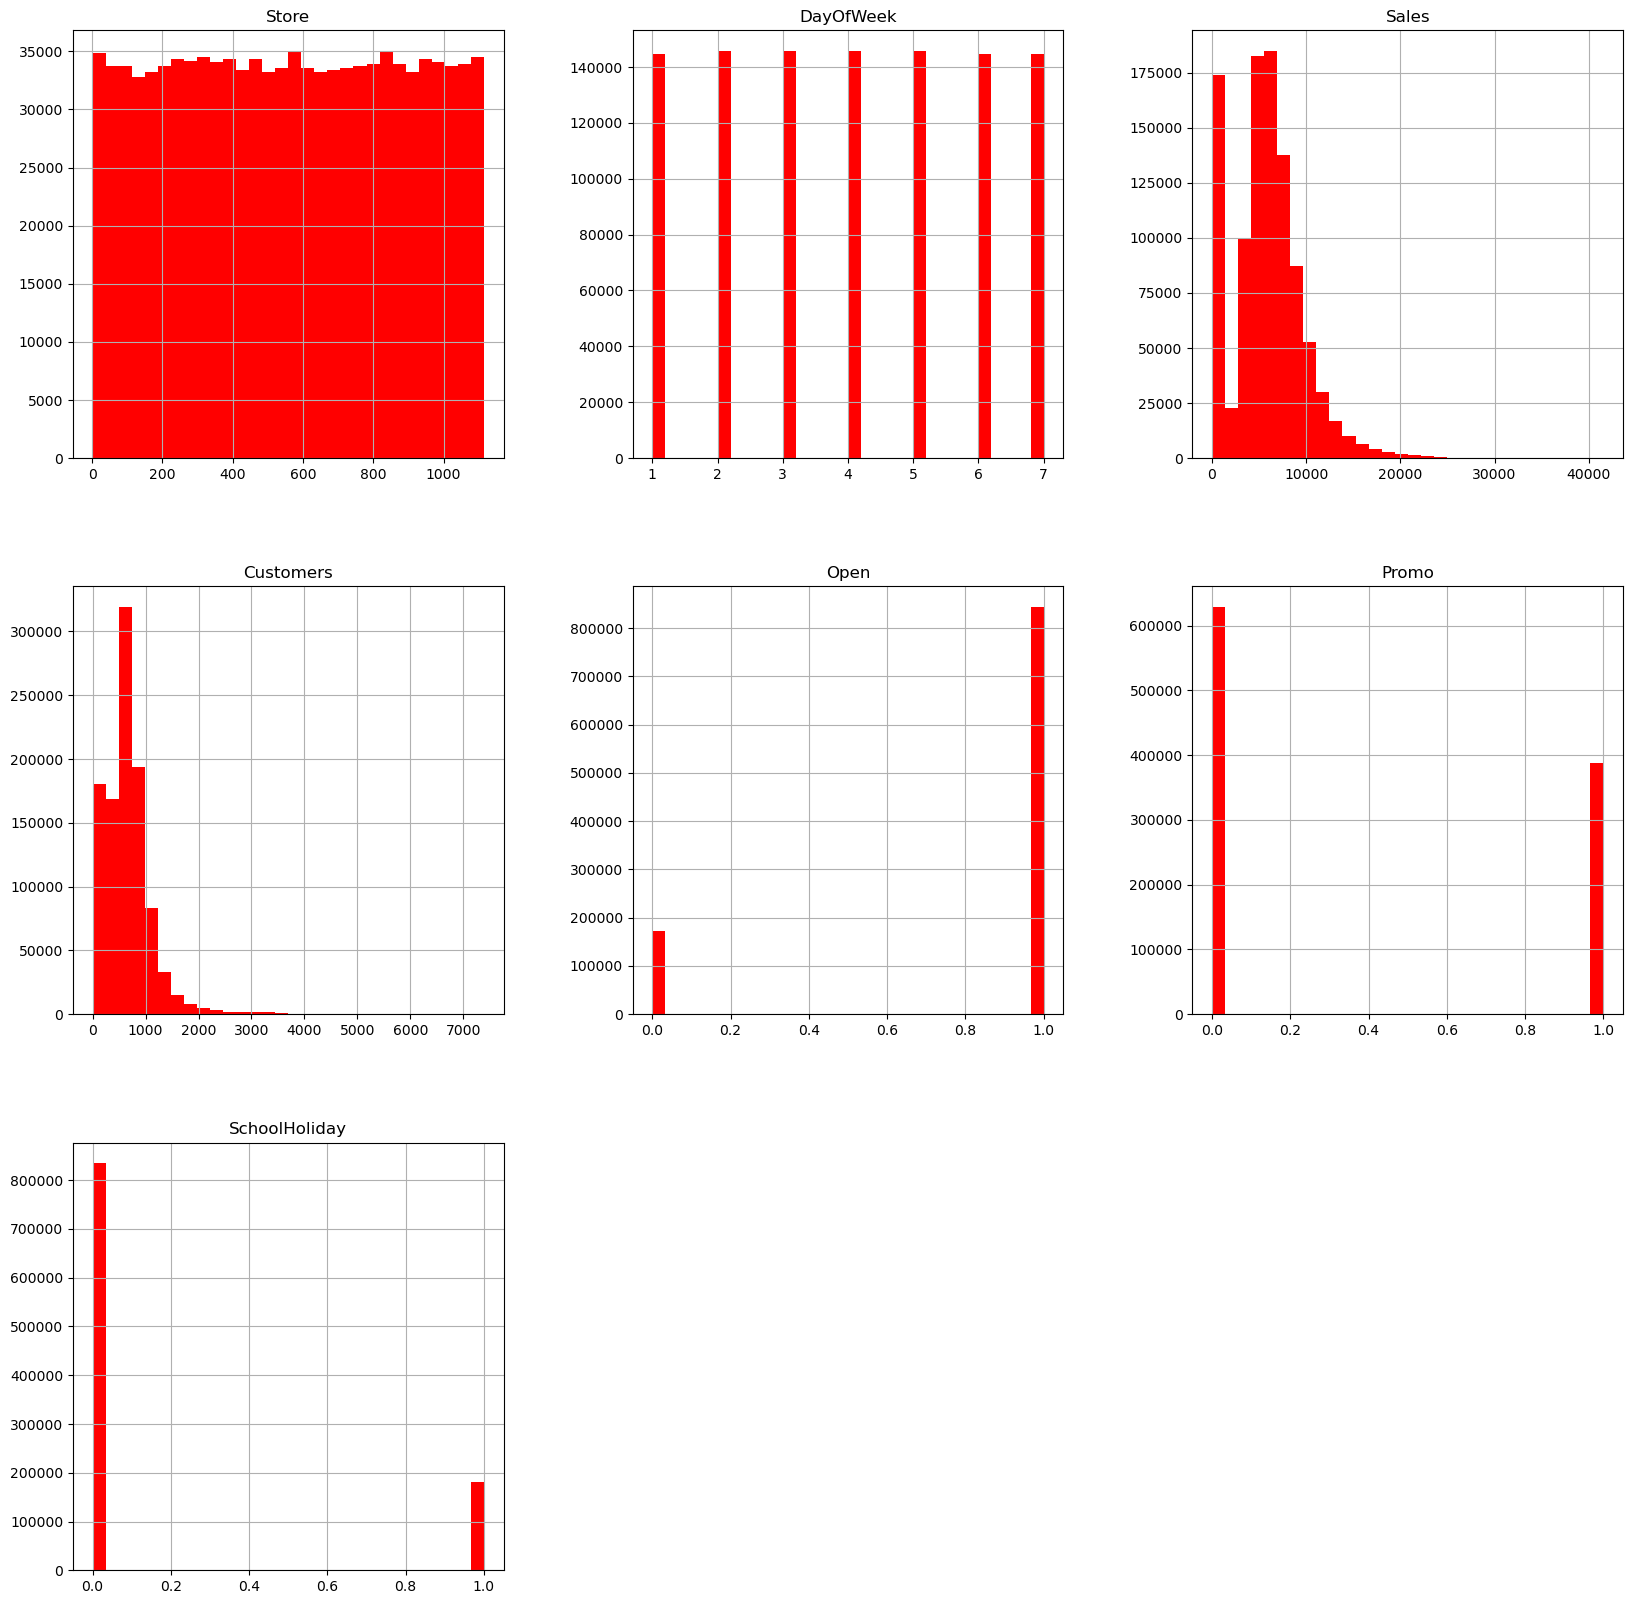

In [39]:
# Observaremos los histogramas de cada variable para decidir si eliminar alguna de ellas...
ventas.hist(bins = 30, figsize = (20, 20), color ='r')

### Conclusiones.
##### 1.- Los datos se distribuyen por igual en varios días de la semana.
##### 2.- La mayoría de las ventas se encuentran entre los 3000 y 12000 Euros.
##### 3.- Promedio de 600 clientes por día, la mayoría entre 0 y 4500.
##### 4.- Las tiendas están abiertas aproximadamente el 80% del tiempo.
##### 5.- La promoción # 1 se ejecutó aproximadamente el 40% del tiempo.
##### 6.- Los datos se distribuyen por igual entre todas las tiendas (sin sesgo)
##### 7.- Las vacaciones escolares duran alrededor del 18% del tiempo.

### 3.1.3 Separar la variable OPEN.

In [49]:
# Contamos el número de tiendas abiertas y cerradas.
open_df = ventas[ventas['Open'] == 1]
close_df = ventas[ventas['Open'] == 0]
print("La cantidad de informes que se han recolectado entre todas las tiendas son {}, "
      "la cantidad de informes generados los días que han abierto las tiendas son {} "
      "y la cantidad de informes generados los días que las tiendas han cerrado son {}.".format(len(ventas),len(open_df),len(close_df)))

print("Por lo tanto, un {:.1f}% de los informes entregan información de cuando la tienda permanecía "
      "cerrada.".format(len(close_df)*100/len(ventas)))# Número de cierre / número total

La cantidad de informes que se han recolectado entre todas las tiendas son 1017209, la cantidad de informes generados los días que han abierto las tiendas son 844392 y la cantidad de informes generados los días que las tiendas han cerrado son 172817.
Por lo tanto, un 17.0% de los informes entregan información de cuando la tienda permanecía cerrada.


In [50]:
# Nos quedaremos solo con un dataset de informes de los días que las tiendas estuvieron abiertas.
ventas = ventas[ventas['Open'] == 1]
ventas

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,1,0,a,1
1016827,733,2,2013-01-01,10765,2377,1,0,a,1
1016863,769,2,2013-01-01,5035,1248,1,0,a,1
1017042,948,2,2013-01-01,4491,1039,1,0,a,1


In [51]:
# Eliminar columna open, ya que ahora no tiene sentido.
ventas.drop(['Open'], axis = 1, inplace=True)
ventas

C:\Users\Danko\AppData\Local\Temp\ipykernel_16092\1107376925.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ventas.drop(['Open'], axis = 1, inplace=True)


,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,0,1
1,2,5,2015-07-31,6064,625,1,0,1
2,3,5,2015-07-31,8314,821,1,0,1
3,4,5,2015-07-31,13995,1498,1,0,1
4,5,5,2015-07-31,4822,559,1,0,1
...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,0,a,1
1016827,733,2,2013-01-01,10765,2377,0,a,1
1016863,769,2,2013-01-01,5035,1248,0,a,1
1017042,948,2,2013-01-01,4491,1039,0,a,1


In [53]:
# Revisamos los cambios al eliminar los días en los que no hubo ventas, no hubo clientes, etc.
ventas.describe()

,Store,DayOfWeek,Sales,Customers,Promo,SchoolHoliday
count,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000
mean,558.422920,3.520361,6955.514291,762.728395,0.446352,0.193580
std,321.731914,1.723689,3104.214680,401.227674,0.497114,0.395103
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,280.000000,2.000000,4859.000000,519.000000,0.000000,0.000000
50%,558.000000,3.000000,6369.000000,676.000000,0.000000,0.000000
75%,837.000000,5.000000,8360.000000,893.000000,1.000000,0.000000
max,1115.000000,7.000000,41551.000000,7388.000000,1.000000,1.000000


### Observación.
#### Ventas promedio = 6955 Euros, número promedio de clientes = 762.
#### Los promedios en la información del dataset han subido.

## 3.2 Explorar data set de tiendas.

### 3.2.1 Hallar nulos.

In [54]:
# Veamos si nos faltan datos (cantidad de datos nulos)
# Se puede revisar y contar cuántos son usando la función .isna y también se puede ordenar en forma
# ascendente.
tiendas.isna().sum().sort_values(ascending = False)

Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
CompetitionDistance            3
Store                          0
StoreType                      0
Assortment                     0
Promo2                         0
dtype: int64

### 3.2.2 Imputación de nulos.

In [56]:
# Imputaremos los valores de promos y de apertura de la competencia por cero. Esto, dado que los datos nulos en las
# promos'Promo2SinceWeek', 'Promo2SinceYear' y 'PromoInterval', se condicen, al ser la misma tienda que no realiza
# promociones. Esto quiere decir que cualquier otro número para imputar, por ejemplo el promedio, afectaría
# inconsistentemente a las conclusiones que se desprendan. 
tiendas.loc[(tiendas['Promo2SinceWeek'].isnull() == True), 'Promo2SinceWeek'] = 0
tiendas.loc[(tiendas['Promo2SinceYear'].isnull() == True), 'Promo2SinceYear'] = 0
tiendas.loc[(tiendas['PromoInterval'].isnull() == True), 'PromoInterval'] = 0

# Lo mismo pasa con la fecha de apertura, ya que se tiene la distancia de la competición, pero no la fecha de apertura,
# cosa que significaría que no es un problema de distancia el hecho de no saber cual es la fecha de apertura de la
# competencia.
tiendas.loc[(tiendas['CompetitionOpenSinceMonth'].isnull() == True), 'CompetitionOpenSinceMonth'] = 0
tiendas.loc[(tiendas['CompetitionOpenSinceYear'].isnull() == True), 'CompetitionOpenSinceYear'] = 0

# Con la distancia de la competencia, se puede reemplazar tranquilamente por el promedio. Solo son 3 datos y tiene
# sentido reemplazar por la media.
tiendas.loc[(tiendas['CompetitionDistance'].isnull() == True), 'CompetitionDistance'] = tiendas['CompetitionDistance'].mean

In [57]:
# Revisamos:
tiendas.isna().sum().sort_values(ascending = False)

Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

### 3.2.2 Observar histogramas.

array([[<AxesSubplot: title={'center': 'Store'}>,
        <AxesSubplot: title={'center': 'CompetitionOpenSinceMonth'}>],
       [<AxesSubplot: title={'center': 'CompetitionOpenSinceYear'}>,
        <AxesSubplot: title={'center': 'Promo2'}>],
       [<AxesSubplot: title={'center': 'Promo2SinceWeek'}>,
        <AxesSubplot: title={'center': 'Promo2SinceYear'}>]], dtype=object)

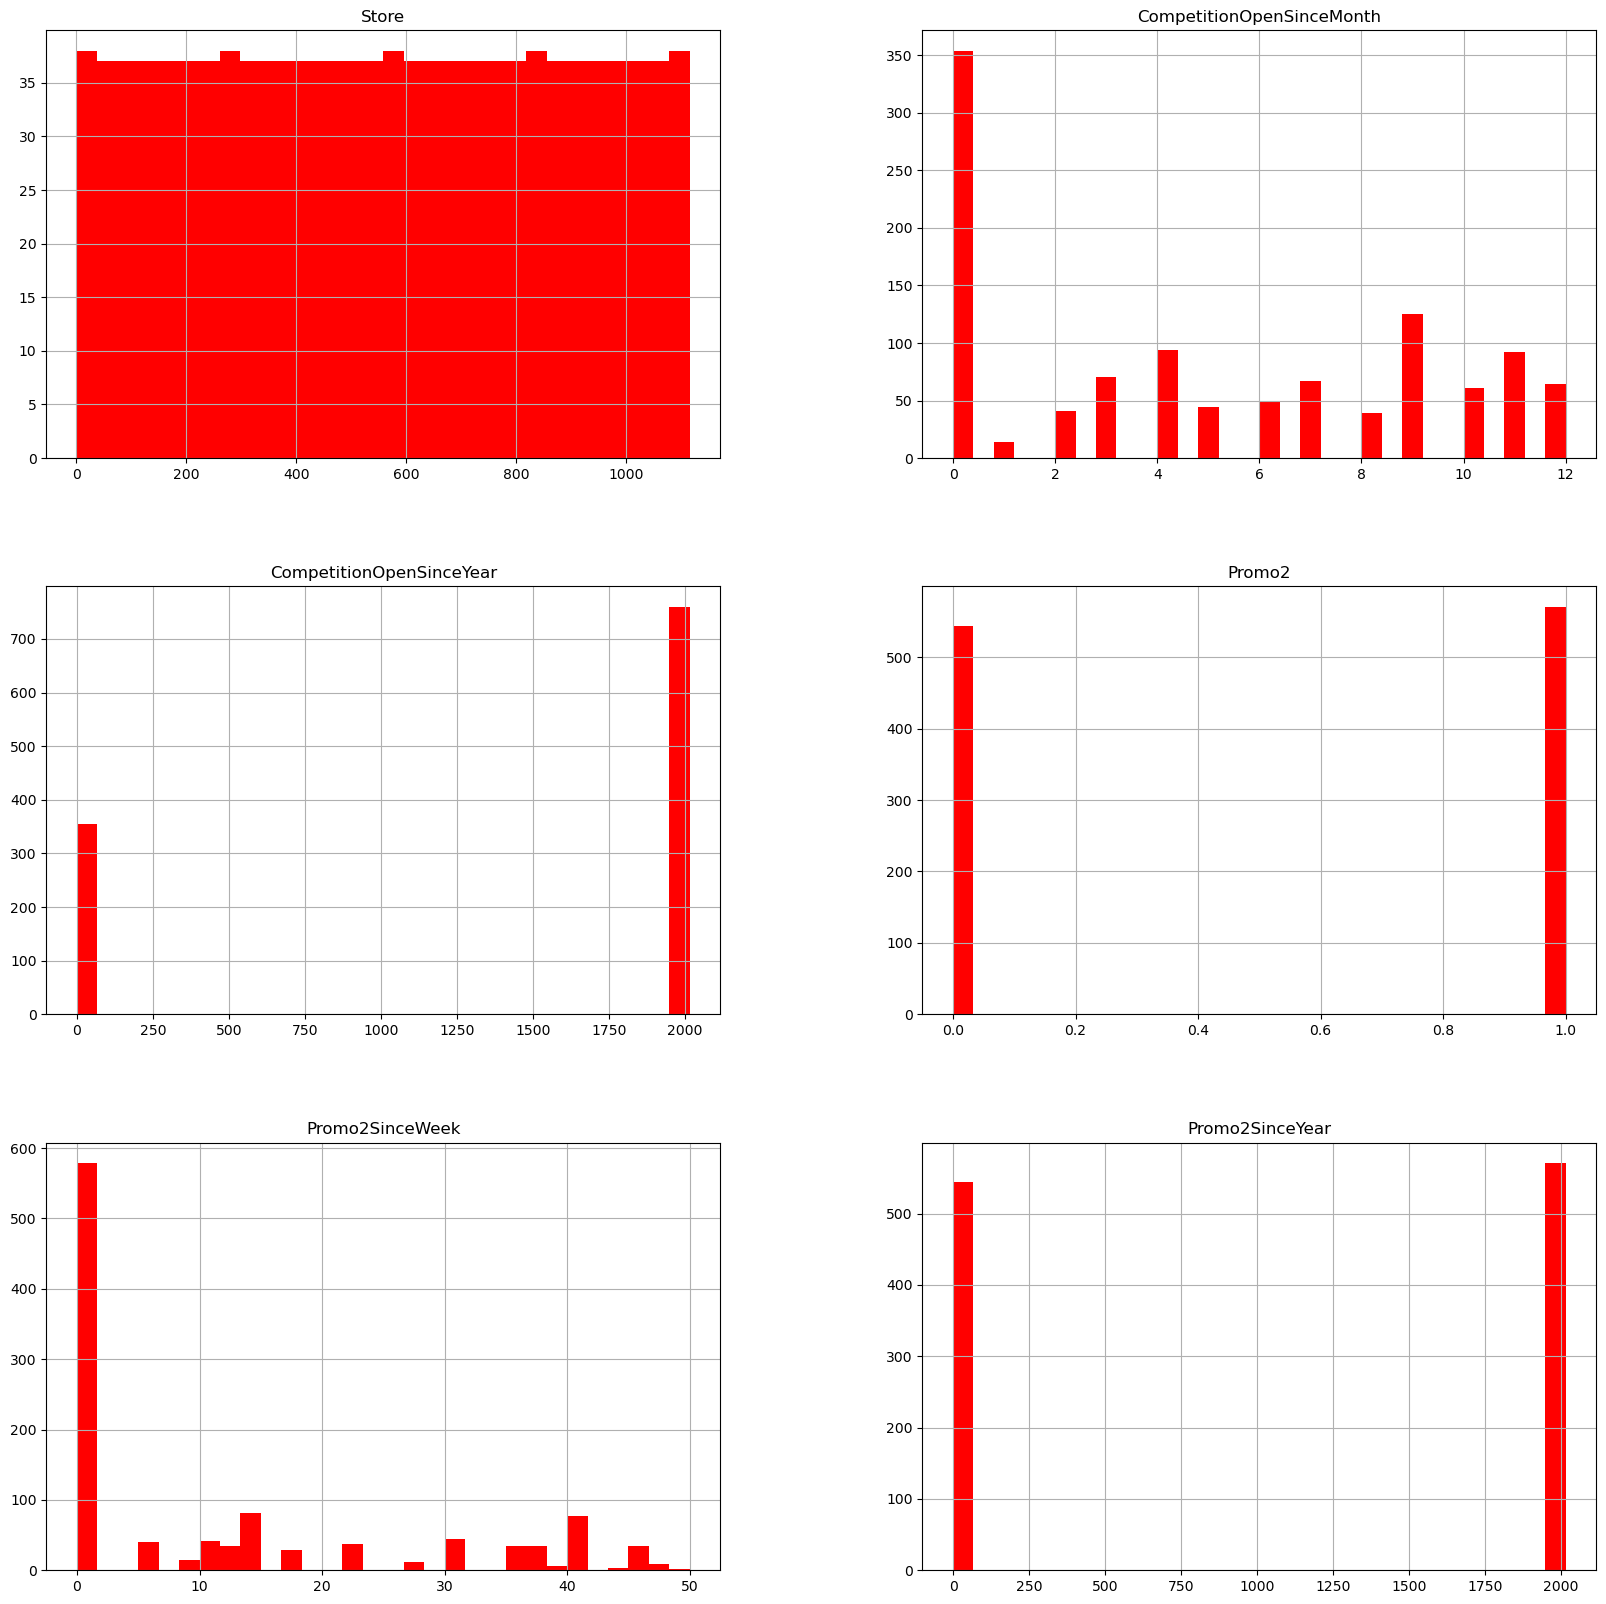

In [58]:
# Observaremos los histogramas de cada variable para decidir si eliminar alguna de ellas...
tiendas.hist(bins = 30, figsize = (20, 20), color ='r')

TAREA #3.3: EXPLOREMOS EL DATASET COMBINADO

In [24]:
# Combinemos ambos data frames en función de 'store'


In [25]:

# los clientes y la promoción se correlacionan positivamente con las ventas
# Promo2 no parece ser efectivo en absoluto

In [26]:

# Los clientes / Promo2 y las ventas están fuertemente correlacionados

In [27]:
# Separemos el año y pongámoslo en una columna separada

In [28]:
# Hagamos lo mismo para el día y el mes


In [29]:
# Echemos un vistazo a las ventas promedio y la cantidad de clientes por mes.
# 'groupby' funciona muy bien al agrupar todos los datos que comparten la misma columna del mes, luego obtener la media de la columna de ventas
# Parece que las ventas y el número de clientes alcanzan su punto máximo en el período de Navidad

In [30]:
# Echemos un vistazo a las ventas y a los clientes por día del mes.
# El número mínimo de clientes suele rondar el día 24 del mes.
# La mayoría de los clientes y las ventas son alrededor del 30 y el 1 del mes


In [31]:
# Hagamos lo mismo para el día de la semana (notemos que 7 = domingo)


# TAREA # 4: ENTENDER LA INTUICIÓN DETRÁS DE FACEBOOK PROPHET

![alt text](https://drive.google.com/uc?id=1zk5cwXQvqci6hOwXoTSU0DY0Dpt1jNF0)

![alt text](https://drive.google.com/uc?id=10HNgyFmM1CG6yzSxpFudunUaHKNV_xBT)

![alt text](https://drive.google.com/uc?id=1BhEzmHYh_HKDWGz4eXP-clF7KAxJ_Od7)

# TAREA # 5: ENTRENAR AL MODELO PARTE A

In [32]:
# import prophet 

# TAREA # 6: ENTRENAR AL MODELO PARTE B

- StateHoliday: indica si el día era festivo o no (a = vacaciones públicas, b = vacaciones de Pascua holiday, c = Navidades, 0 = No era festivo)
- SchoolHoliday: indica si (Store, Date) se ve afectado por el cierre de las escuelas públicas
  






In [33]:
# Obtener todas las fechas relacionadas con las vacaciones escolares

In [34]:
# Obtener todas las fechas correspondientes a los festivos estatales


In [35]:
# Concatenamos las vacaciones escolares y los festivos estatales


In [36]:
# Hagamos predicciones usando días festivos para una tienda específica


# BUEN TRABAJO!!!